In [ ]:
import numpy as np
import pandas as pd
import psycopg2

from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
from pykalman import KalmanFilter


In [3]:
def KFHedgeRatio(x, y):
    """Estimate Hedge Ratio"""
    delta = 1e-3
    trans_cov = delta / (1 - delta) * np.eye(2)
    obs_mat = np.expand_dims(np.vstack([[x], [np.ones(len(x))]]).T, axis=1)

    kf = KalmanFilter(n_dim_obs=1, n_dim_state=2,
                      initial_state_mean=[0, 0],
                      initial_state_covariance=np.ones((2, 2)),
                      transition_matrices=np.eye(2),
                      observation_matrices=obs_mat,
                      observation_covariance=2,
                      transition_covariance=trans_cov)

    state_means, _ = kf.filter(y.values)
    return -state_means

def KFSmoother(prices):
    """Estimate rolling mean"""
    
    kf = KalmanFilter(transition_matrices=np.eye(1),
                      observation_matrices=np.eye(1),
                      initial_state_mean=0,
                      initial_state_covariance=1,
                      observation_covariance=1,
                      transition_covariance=.05)

    state_means, _ = kf.filter(prices.values)
    return pd.Series(state_means.flatten(),
                     index=prices.index)

In [4]:
critical_values = {0: {.9: 13.4294, .95: 15.4943, .99: 19.9349},
                   1: {.9: 2.7055, .95: 3.8415, .99: 6.6349}}

trace0_cv = critical_values[0][.95] # critical value for 0 cointegration relationships
trace1_cv = critical_values[1][.95] # critical value for 1 cointegration relationship

In [5]:
conn = psycopg2.connect(dbname="analysis", host="acer", user='yzhang2', password='analysis')
cursor = conn.cursor()

sqlstm = "SELECT * FROM yahooastock1d"
cursor.execute(sqlstm)
results = cursor.fetchall()
stock_data = pd.DataFrame(results, columns=[desc[0] for desc in cursor.description])
stock_data['trade_date'] = pd.to_datetime(stock_data['trade_date'])

OperationalError: could not translate host name "acer" to address: Name or service not known


In [ ]:
stock_codes = list(stock_data['stock_code'].unique())

In [1]:
for i in range(len(stock_codes)):
    pricediff = None
    for j in range(i+1, len(stock_codes)):
        stock_code1 = stock_codes[i]
        stock_code2 = stock_codes[j]
        
        data1 = stock_data[stock_data['stock_code'] == stock_code1][['trade_date', 'close']]
        data2 = stock_data[stock_data['stock_code'] == stock_code2][['trade_date', 'close']]
        result = data1.merge(data2, on='trade_date', how='inner')
        cj = coint_johansen(result[['close_x', 'close_y']], det_order=1, k_ar_diff=1)
        if cj.trace_stat[0] > cj.trace_stat_crit_vals[0][1]:
            print(f"Cointegration found for {stock_code1} and {stock_code2}")
            pricediff = result[['close_x', 'close_y']] @ cj.evec[0]
            break
    if pricediff is not None:
        break

        

NameError: name 'stock_codes' is not defined

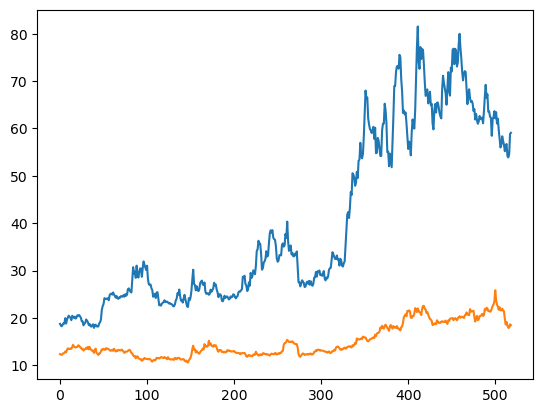

In [18]:
plt.plot(result['close_x'])
plt.plot(result['close_y'])

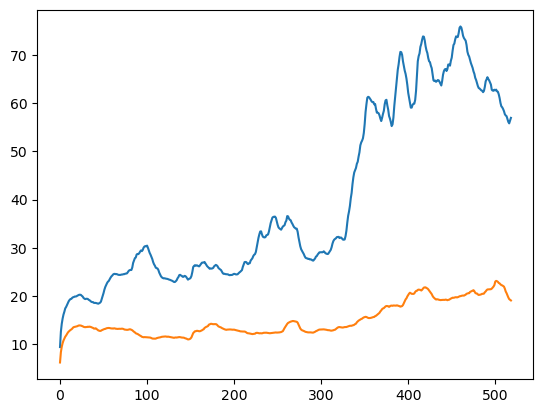

In [21]:
filtered_close_x = KFSmoother(result['close_x'])
filtered_close_y = KFSmoother(result['close_y'])
plt.plot(filtered_close_x)
plt.plot(filtered_close_y)

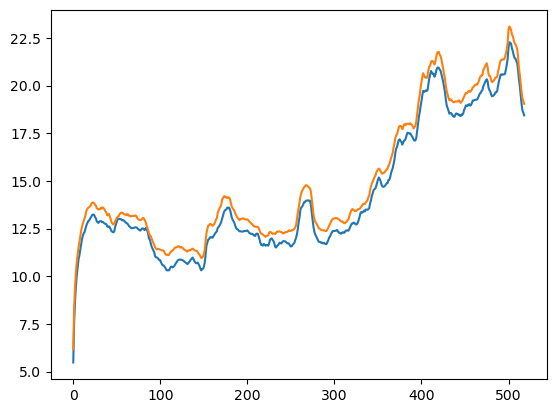

In [36]:
hedge_ratio = KFHedgeRatio(filtered_close_x, filtered_close_y)[:,0]

target_y = -1.0 * hedge_ratio * filtered_close_x
plt.plot(target_y)
plt.plot(filtered_close_y)


In [39]:
print(stock_code1, stock_code2)

save_data1 = stock_data[stock_data['stock_code'] == stock_code1]
save_data2 = stock_data[stock_data['stock_code'] == stock_code2]
save_data = pd.concat([save_data1, save_data2])
save_data.shape, stock_data.shape

603228.SS 002056.SZ


((1038, 7), (410748, 7))

In [42]:
import pickle
with open('testdata.pickle', 'wb') as f:
    pickle.dump(save_data, f)
